# 04 - Generalisation

## From selection to trust

Generalisation asks where a selected rule is defensible beyond the data that selected it.


Notebook 03 showed how $\mathcal{H}$, $\mathcal{D}$, and $\mathcal{O}$ select a rule $s=h_{\hat{\theta}}$.

This notebook asks the next question:

> When should the selected rule be trusted beyond the evidence that selected it?

A fitted solar-panel power rule can work on the tilt-power observations used by the optimizer and fail at new panel-tilt settings, in sparse regions, in gaps, or outside the sampled range. In Notebook 00 language, we now ask whether $s$ belongs in the acceptable solution space $\mathcal{S}$.

We use $\Omega$ for the region where the rule needs to work. A model is best defended where the data, model class, and selection rule constrain its behaviour.

Route:

1. separate fitting evidence from checking evidence;
2. watch training and held-out scores diverge as $\mathcal{H}$ grows;
3. use train, validation, and test roles deliberately;
4. inspect local support in $\Omega$;
5. change $\mathcal{D}$ while holding $\mathcal{H}$ and $\mathcal{O}$ fixed;
6. defend a model choice as an argument about $\mathcal{H}$, $\mathcal{D}$, $\mathcal{O}$, and $\Omega$.

Change one variable at a time, rerun the relevant cells, and ask which part of the learning frame changed.

**Opening hook.** A fitted curve can score well on the evidence that selected it and still be a weak deployment rule. Generalisation is the argument that the selected rule remains defensible on evidence it did not use.


## Narrative route

The route turns a fitted rule into a defensibility argument.


The plain question in this notebook is: **does the fitted model still work on data it did not use?**

We start with a simple train/check split. The training evidence fits the curve. The held-back evidence asks whether that curve works on unseen tilt-power observations. This makes underfitting and overfitting visible: a model can be too simple to learn the pattern, or flexible enough to fit the training evidence while failing on held-back evidence.

Then we separate three roles: train, validation, and test. Training fits parameters. Validation helps choose modelling settings. Test is saved for the final check after the workflow is settled.

Finally, we look at where the model is being used. A random split asks whether future evidence looks like another sample from the same data source. A structured split can ask a harder question, such as whether the model works in a new panel-tilt region, future time period, installation type, or operating condition. That leads to interpolation and extrapolation: predictions between well-supported observations are usually easier to defend than predictions in gaps or outside the observed range, but even interpolation has guarantees only under specific assumptions.


### Key words used here

| Term | Plain meaning |
|---|---|
| Training evidence | Solar-panel observations the optimizer can use to fit parameters. |
| Validation evidence | Held-back solar-panel observations used while choosing modelling settings. |
| Test evidence | Held-back solar-panel observations used once for the final check. |
| Deployment region $\Omega$ | The input region where the model must be useful. |
| Interpolation | Predicting inside a region with nearby observed inputs. |
| Gap | Predicting inside the observed range but far from observed inputs. |
| Extrapolation | Predicting outside the observed input range. |


### What to watch for

A score is useful, but it is not the whole argument. Always ask which evidence shaped the model, which evidence checked it, how the split was made, and whether the checking evidence covers the region where the model will be used.


<br>

## 1. Learning objectives

These objectives name the skills to practice in this notebook.


By the end, you should be able to:

1. use a train/check split to test performance on unseen evidence;
2. recognise underfitting and overfitting from training and held-out scores;
3. distinguish training, validation, test, and deployment roles;
4. explain why random and structured splits answer different questions;
5. define interpolation, gaps, and extrapolation in the input space;
6. explain what simple interpolation guarantees do and do not prove;
7. build a defensible model-choice argument using $\mathcal{H}$, $\mathcal{D}$, $\mathcal{O}$, and the deployment region $\Omega$.


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


<br>

## 2. Start With Fit and Check Evidence

Fitting evidence and checking evidence play different roles.


Notebook 03 used the same solar-panel calibration evidence both to fit a curve and score candidate curves. That was useful for understanding $\mathcal{O}$, but it cannot answer whether the selected rule works on new evidence.

Start with one finite dataset and split it into two roles:

- $\mathcal{D}_{fit}$ is the training evidence. The optimizer can use it to select $\hat{\theta}$ for a fixed modelling choice.
- $\mathcal{D}_{check}$ is held back. It checks the fitted curve on evidence that did not choose $\hat{\theta}$.

This first split is only a teaching diagnostic. Its job is to make the key distinction visible: the score used to fit a rule is not the same as a score measured after the rule has already been fitted.

The distinction matters because a flexible model can specialise to the evidence it sees. If the same evidence both chooses the rule and judges the rule, the judgement is partly circular. A held-back check set asks a cleaner question: after fitting has happened, does the curve still make reasonable predictions on evidence it did not use?

The shape of the split matters as much as the amount of evidence. A check point close to many training points is a local interpolation check. A check point in a sparse gap or beyond the training range is a harder check, because the model has less nearby evidence.

Before looking at errors, inspect the split. Which parts of $\Omega$ are covered by training evidence? Where would two plausible curves have room to disagree? Which held-back points are asking for interpolation, and which ones are closer to extrapolation?


### 2.1 Before running: separate the roles of evidence

The next cells split one finite dataset into two roles.

| Evidence role | What it is allowed to do |
|---|---|
| $\mathcal{D}_{fit}$ | Fit parameters for a fixed modelling choice. |
| $\mathcal{D}_{check}$ | Check the already-fitted rule on evidence that did not fit it. |

Before running, predict which panel-tilt regions will be checked strongly and which will remain weakly supported.


In [2]:
# Build a dataset and split it into evidence used for fitting and evidence held out for checking.
n_samples = 30
noise_std = 0.20
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"
check_size = 0.35

x_full, y_full = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)
x_train, y_train, x_check, y_check = data.train_test_split_for_workshop(
    x_full,
    y_full,
    test_size=check_size,
    seed=seed + 1,
)

print_rows(
    [
        {"split": "D_fit", "n": len(x_train), "x_min": np.min(x_train), "x_max": np.max(x_train)},
        {"split": "D_check", "n": len(x_check), "x_min": np.min(x_check), "x_max": np.max(x_check)},
    ],
    title="Fit/check split summary",
)


Fit/check split summary
01. split=D_fit, n=20, x_min=0.1954, x_max=0.9199
02. split=D_check, n=10, x_min=0.0128, x_max=0.9670


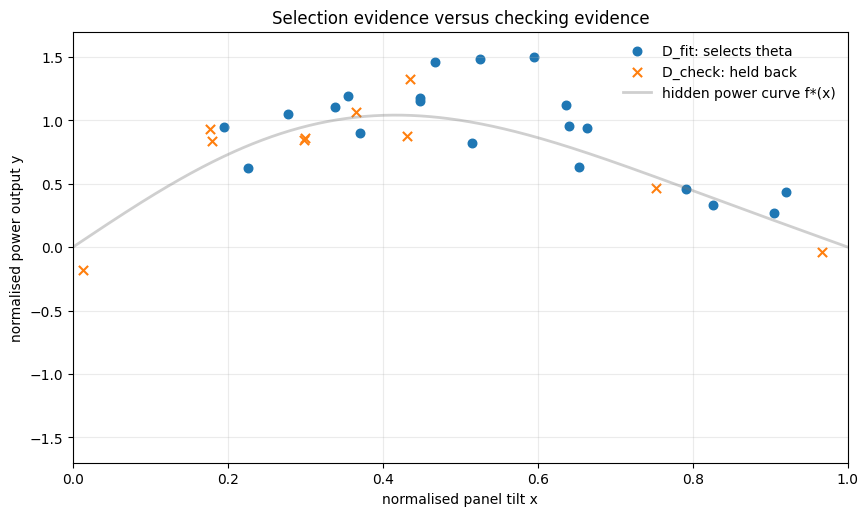

In [3]:
# See which points the optimizer can use and which points are held back.
x_grid = data.make_test_grid(n_points=500)
fig, ax = plt.subplots(figsize=(10.0, 5.6))
ax.scatter(x_train, y_train, s=38, color="#1f77b4", label="D_fit: selects theta")
ax.scatter(x_check, y_check, s=44, color="#ff7f0e", marker="x", label="D_check: held back")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
ax.set_title("Selection evidence versus checking evidence")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


### 2.2 Before running: predict underfitting and overfitting


> **Predict before running.** The next cells keep the fitting rule fixed and vary polynomial degree. In workshop terms, that changes the hypothesis space $\mathcal{H}$ while the optimizer still uses $\mathcal{D}_{fit}$.
>
> Before running the comparison, predict which degree will have the lowest fit MSE, which degree will have the lowest check MSE, and which degree will look least defensible away from measured panel tilts. Name whether your prediction is mostly about $\mathcal{H}$, $\mathcal{D}$, or $\mathcal{O}$.


In [4]:
# Fit several degrees and compute the fit and check questions separately.
degrees_to_score = (0, 1, 3, 5, 9)
score_grid = data.make_test_grid(n_points=500)
score_rows = []
score_fits = {}

for degree in degrees_to_score:
    coeffs = models.fit_polynomial_mle(x_train, y_train, degree=degree)
    fit_pred = models.predict_polynomial(x_train, coeffs)
    check_pred = models.predict_polynomial(x_check, coeffs)
    score_fits[degree] = models.predict_polynomial(score_grid, coeffs)
    score_rows.append(
        {
            "degree": degree,
            "n_features": degree + 1,
            "fit_mse": metrics.mse(y_train, fit_pred),
            "check_mse": metrics.mse(y_check, check_pred),
            "coef_norm": metrics.coefficient_norm(coeffs),
        }
    )

best_fit = min(score_rows, key=lambda row: row["fit_mse"])
best_check = min(score_rows, key=lambda row: row["check_mse"])

print_rows(score_rows, digits=4, title="Fit and check error by hypothesis-space size")
print_rows(
    [
        {"criterion": "lowest_fit_mse", **best_fit},
        {"criterion": "lowest_check_mse", **best_check},
    ],
    digits=4,
    title="Different criteria can favour different selected models",
)


Fit and check error by hypothesis-space size
01. degree=0, n_features=1, fit_mse=0.1321, check_mse=0.2583, coef_norm=0.9280
02. degree=1, n_features=2, fit_mse=0.0953, check_mse=0.3508, coef_norm=1.6875
03. degree=3, n_features=4, fit_mse=0.0438, check_mse=0.0603, coef_norm=19.5088
04. degree=5, n_features=6, fit_mse=0.0350, check_mse=0.5581, coef_norm=86.5834
05. degree=9, n_features=10, fit_mse=0.0283, check_mse=3116.0791, coef_norm=1.17e+06
Different criteria can favour different selected models
01. criterion=lowest_fit_mse, degree=9, n_features=10, fit_mse=0.0283, check_mse=3116.0791, coef_norm=1.17e+06
02. criterion=lowest_check_mse, degree=3, n_features=4, fit_mse=0.0438, check_mse=0.0603, coef_norm=19.5088


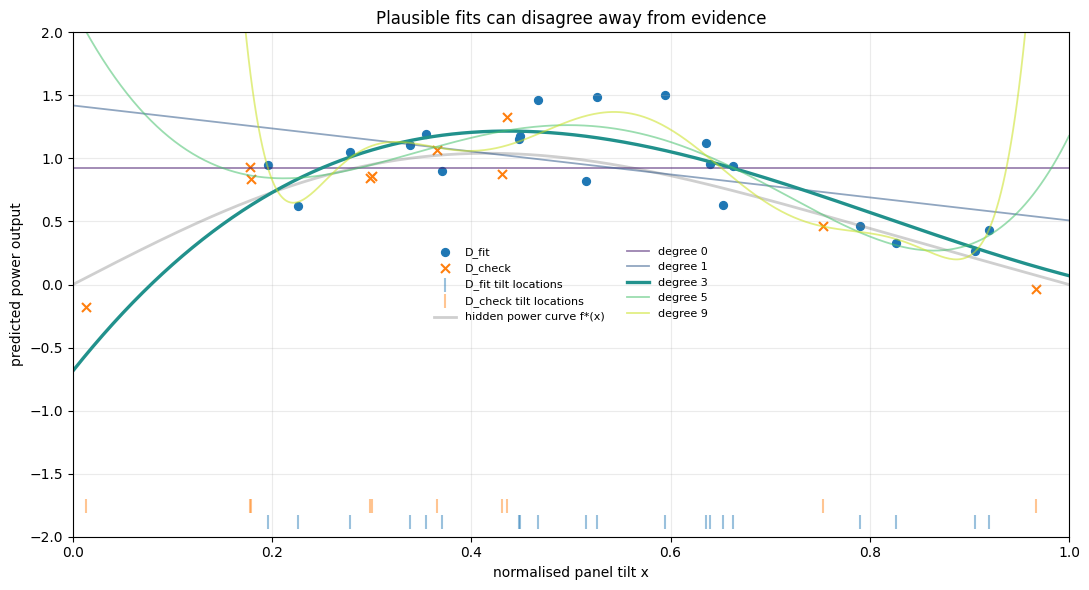

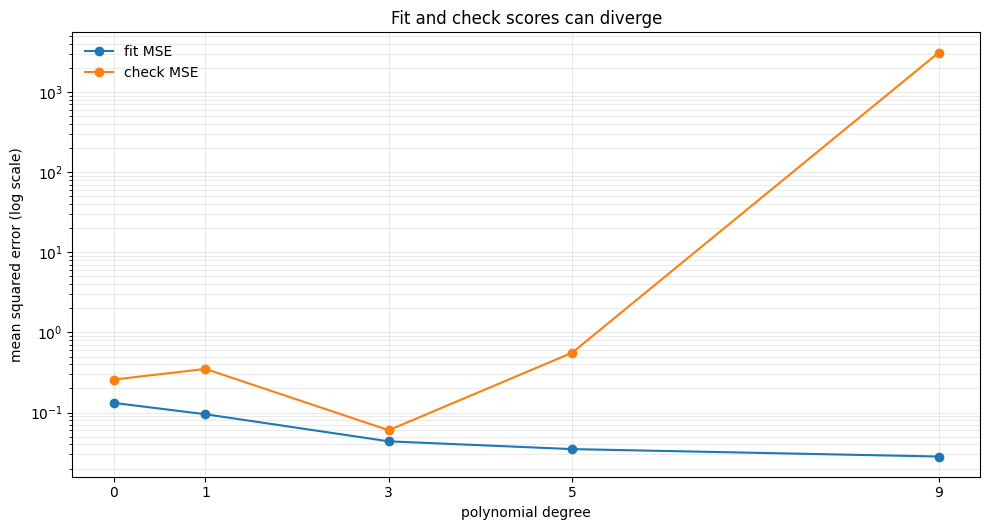

In [5]:
# Compare the selected curves and the score summaries.
degree_values = [row["degree"] for row in score_rows]
fit_mse_values = [row["fit_mse"] for row in score_rows]
check_mse_values = [row["check_mse"] for row in score_rows]

fig_curve, ax_curve = plt.subplots(figsize=(11.0, 6.0))

ax_curve.scatter(x_train, y_train, s=32, color="#1f77b4", label="D_fit")
ax_curve.scatter(x_check, y_check, s=42, color="#ff7f0e", marker="x", label="D_check")
ax_curve.scatter(x_train, np.full_like(x_train, -1.88), marker="|", s=90, color="#1f77b4", alpha=0.45, label="D_fit tilt locations")
ax_curve.scatter(x_check, np.full_like(x_check, -1.76), marker="|", s=90, color="#ff7f0e", alpha=0.45, label="D_check tilt locations")
ax_curve.plot(score_grid, data.true_function(score_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
colors = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(degrees_to_score)))
for color, degree in zip(colors, degrees_to_score):
    linewidth = 2.4 if degree == best_check["degree"] else 1.3
    alpha = 1.0 if degree == best_check["degree"] else 0.55
    ax_curve.plot(score_grid, score_fits[degree], color=color, linewidth=linewidth, alpha=alpha, label=f"degree {degree}")
ax_curve.set_title("Plausible fits can disagree away from evidence")
ax_curve.set_xlabel("normalised panel tilt x")
ax_curve.set_ylabel("predicted power output")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.0, 2.0)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8, ncol=2)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_score, ax_score = plt.subplots(figsize=(10.0, 5.4))
ax_score.plot(degree_values, fit_mse_values, marker="o", label="fit MSE")
ax_score.plot(degree_values, check_mse_values, marker="o", label="check MSE")
ax_score.set_yscale("log")
ax_score.set_title("Fit and check scores can diverge")
ax_score.set_xlabel("polynomial degree")
ax_score.set_ylabel("mean squared error (log scale)")
ax_score.set_xticks(degree_values)
ax_score.grid(alpha=0.25, which="both")
ax_score.legend(frameon=False)
fig_score.tight_layout()
show_fig(fig_score)


### 2.3 After running: diagnose overfitting as a travel problem

Compare fit error and check error.

- If fit error falls while check error worsens, the selected rule is becoming specialised to the evidence that selected it.
- If both errors are high, the hypothesis space or selection rule may be too limited for the pattern.
- If check error is low but local plots look weak in an important region, the average score may be hiding a support problem.

Generalisation asks whether the selected rule travels beyond the evidence used for selection.


**What the First Diagnostic Shows**

The first diagnostic used $\mathcal{D}_{fit}$ and $\mathcal{D}_{check}$ to separate evidence that selects parameters from evidence that checks the selected rule.

The fit split is allowed to choose parameters. For a fixed degree and fitting rule, it supplies the evidence used to construct $\hat{\theta}$. It can tell us which curve was fitted, but it cannot by itself tell us whether that curve works on new evidence.

The check split asks how the already-fitted solar-panel power rule behaves on cases that did not fit it. If we repeatedly use that check split to pick degrees, tune preprocessing, remove examples, or rewrite the workflow, it stops being an untouched check and becomes validation evidence.

In learning-frame language, the degree changes $\mathcal{H}$, the split changes which part of $\mathcal{D}$ is allowed to select, and least squares keeps $\mathcal{O}$ fixed. The practical warning is direct: a score measured on selection evidence is not the same claim as a score measured after selection.


<br>

## 3. Use Train, Validation, and Test Deliberately

Split roles determine what kind of performance claim is justified.


A held-out check error is useful, but once it guides choices such as degree, preprocessing, or regularisation, it is no longer a final check. It has become validation evidence.

Use a three-way split when the workflow needs a cleaner final claim:

- Training evidence selects $\theta$ for a fixed modelling choice.
- Validation evidence guides modelling choices such as degree, regularisation, preprocessing, and prompts.
- Test evidence is saved for one final check after those choices have settled.

For a fixed modelling choice $m$, training produces:

$$
\hat{\theta}_m = \mathcal{O}_m(\mathcal{D}_{train}).
$$

Validation compares several $m$ values. Test evidence is saved until the workflow is settled. If the test result triggers more tuning, it has become validation evidence and a new final check is needed.

The split policy controls the claim. A random split checks whether future cases look like another sample from the same source. A structured split checks transfer to a held-out time period, installation type, operating condition, or panel-tilt region. Neither policy is universally better; the defensible policy is the one that matches the claim.

The next plot shows the distinction. Random held-out points are spread through the same tilt range as training evidence. Structured held-out points concentrate in one region, so the check asks a harder local transfer question.


### Formulation checkpoint: choose the split policy before scores
A split is not just bookkeeping. Before running the next comparison, decide what question the held-out evidence should answer.

- Random held-out rows ask about average performance under a similar sampling process.
- Structured held-out regions ask whether the rule travels to a specific part of the input space.
- A final test set should answer one claim after modelling choices are fixed.

Write the claim first; then choose the split that can actually test it.


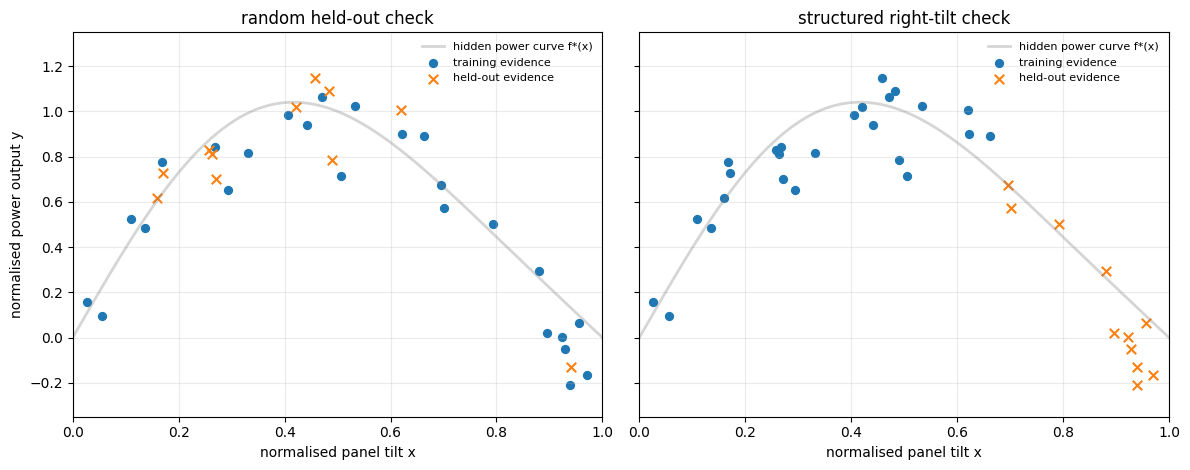

In [6]:
# Compare random and structured split policies on the same solar-panel data.
split_policy_seed = 2042
x_policy, y_policy = data.make_regression_data(
    n=36,
    noise_std=0.18,
    seed=split_policy_seed,
    sampling="uniform",
)
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)

rng = np.random.default_rng(split_policy_seed)
heldout_count = int(round(0.30 * len(x_policy)))
random_heldout = np.zeros(len(x_policy), dtype=bool)
random_heldout[rng.permutation(len(x_policy))[:heldout_count]] = True
structured_cutoff = np.quantile(x_policy, 0.70)
structured_heldout = x_policy >= structured_cutoff

split_policies = [
    ("random held-out check", random_heldout),
    ("structured right-tilt check", structured_heldout),
]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)
for ax, (title, heldout_mask) in zip(axes, split_policies):
    train_mask = ~heldout_mask
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.30, linewidth=2.0, label="hidden power curve f*(x)")
    ax.scatter(x_policy[train_mask], y_policy[train_mask], s=32, color="#1f77b4", label="training evidence")
    ax.scatter(x_policy[heldout_mask], y_policy[heldout_mask], s=46, marker="x", color="#ff7f0e", label="held-out evidence")
    ax.set_title(title)
    ax.set_xlabel("normalised panel tilt x")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.35, 1.35)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("normalised power output y")
fig.tight_layout()
show_fig(fig)


### 3.1 Validation, test, and split policy check

Check:

1. Which choices were influenced by validation evidence?
2. Which evidence remains available for a final test claim?
3. Does the split match the deployment claim: random same-source use, or structured transfer?
4. What would make the final test no longer final?

A validation score helps choose a workflow. A test score checks a settled workflow.


**Diagnose the Selection Pattern**

As the polynomial family becomes more flexible, fit error often falls. That is expected: a larger $\mathcal{H}$ gives the optimizer more ways to match $\mathcal{D}_{fit}$.

One way to write the selected parameter is:

$$
\hat{\theta} = \arg\min_{\theta \in \Theta} \mathcal{L}(\mathcal{D}_{fit}, \theta).
$$

The check observations ask how this selected $\hat{\theta}$ behaves on evidence that did not choose it. If fit error keeps improving while check error worsens, the selected rule has become too specialised to the selection evidence. That is the practical overfitting warning.

Before moving on, decide what would make a model choice defensible: the lowest validation score, a smoother-looking tilt-power curve, a smaller coefficient warning sign, stronger coverage in the deployment tilt region, or some combination of these.


<br>

## 4. Ask Where the Rule Is Supported

Local support asks whether nearby evidence and curve shape justify a prediction at each input.

A held-out score is an average. It does not say where the model is supported.

For the solar-panel problem, support depends on whether the data resolve the power response across the panel-tilt range. Sparse sampling may be fine where the response is flat. It is risky where the response bends or changes quickly.

The local question is:

> Where does evidence constrain the power curve, and where can the fitted rule drift?

A simple interpolation bound gives the intuition. For noiseless function values and a linear interpolant $I_h f$,

$$
\lVert f-I_h f\rVert_\infty \leq \frac{h^2}{8}\max_x |f''(x)|.
$$

Here $h$ is the largest spacing between neighbouring observations, and $|f''(x)|$ measures curvature. Large gaps matter most where the response bends sharply.

This is not a deployment guarantee. It ignores noise, bias, model choice, and extrapolation. It only says that spacing and curvature both matter.

A broader coverage diagnostic is fill distance. For observed panel-tilt settings $\mathcal{D}_x$,

$$
h_{\mathcal{D}_x}(\Omega)=\sup_{x\in\Omega}\min_{z\in\mathcal{D}_x}|x-z|.
$$

It asks how far any deployment point in $\Omega$ is from the nearest observation.

> **Discuss.** Where would you least trust a fitted solar-panel power curve: a sparse region, a high-curvature region, or outside the measured range? What evidence would change your answer?

Read the next plot as a support diagnostic: where is evidence near, where is it absent, and where does the response change quickly?

Then read the evaluation table by region. A global score asks, "How wrong is the fitted rule on average?" A support-aware evaluation asks more precise questions:

- How much does performance vary inside the domain constrained by the data?
- Where are the weakly supported gaps inside the observed range?
- What happens outside the observed range, where the answer depends more strongly on the form of the hypothesis space?

In this simulation we can compare against the hidden solar-panel power curve. In real work, the same idea becomes targeted checking: hold out or collect evidence in the region where the rule will actually be used.



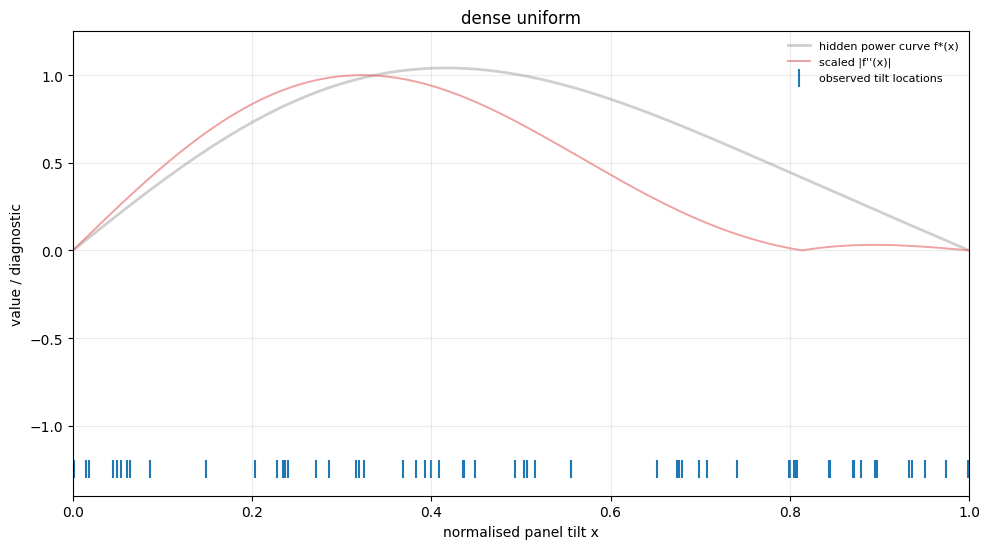

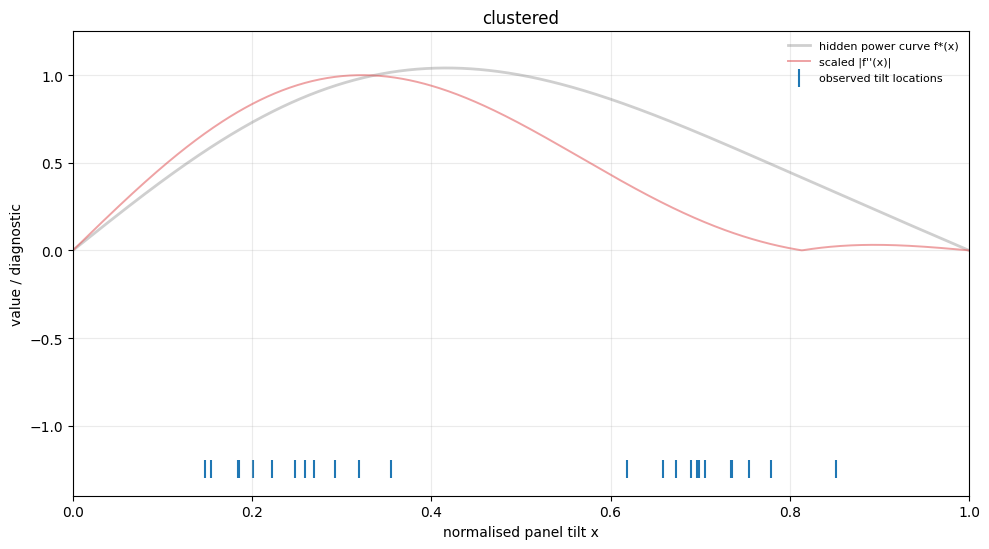

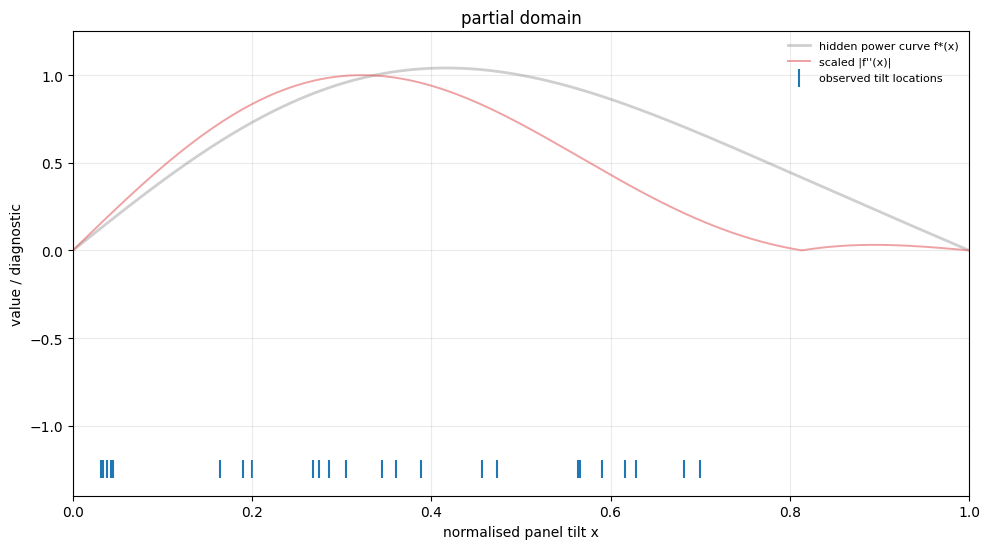

Resolution diagnostics
01. case=dense uniform, n=60, largest_internal_gap=0.0962, fill_distance=0.0480, boundary_extrapolation=0.0012
02. case=clustered, n=24, largest_internal_gap=0.2643, fill_distance=0.1480, boundary_extrapolation=0.1480
03. case=partial domain, n=24, largest_internal_gap=0.1192, fill_distance=0.3006, boundary_extrapolation=0.3006


In [7]:
# Visualise sample spacing, fill distance, and function curvature as resolution diagnostics.
resolution_cases = [
    {"label": "dense uniform", "n": 60, "sampling": "uniform", "seed": 5},
    {"label": "clustered", "n": 24, "sampling": "clustered", "seed": 5},
    {"label": "partial domain", "n": 24, "sampling": "partial_domain", "seed": 5},
]

x_grid = data.make_test_grid(n_points=600)
curvature = np.abs(
    -(np.pi**2) * np.sin(np.pi * x_grid)
    - 0.15 * (2.0 * np.pi) ** 2 * np.sin(2.0 * np.pi * x_grid)
)
curvature_scaled = curvature / np.max(curvature)

resolution_rows = []

for settings in resolution_cases:
    x_res, y_res = data.make_regression_data(
        n=settings["n"],
        noise_std=0.0,
        seed=settings["seed"],
        sampling=settings["sampling"],
    )
    internal_gaps = np.diff(x_res)
    largest_internal_gap = float(np.max(internal_gaps)) if len(internal_gaps) else 0.0
    nearest_distances = np.min(np.abs(x_grid[:, None] - x_res[None, :]), axis=1)
    fill_distance = float(np.max(nearest_distances))
    boundary_extrapolation = float(max(x_res[0] - 0.0, 1.0 - x_res[-1]))
    resolution_rows.append(
        {
            "case": settings["label"],
            "n": settings["n"],
            "largest_internal_gap": largest_internal_gap,
            "fill_distance": fill_distance,
            "boundary_extrapolation": boundary_extrapolation,
        }
    )

    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
    ax.plot(x_grid, curvature_scaled, color="#e15759", alpha=0.55, linewidth=1.4, label="scaled |f''(x)|")
    ax.scatter(x_res, np.zeros_like(x_res) - 1.25, marker="|", s=170, color="#1f77b4", label="observed tilt locations")
    ax.set_title(settings["label"])
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("value / diagnostic")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.4, 1.25)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)

print_rows(resolution_rows, title="Resolution diagnostics")


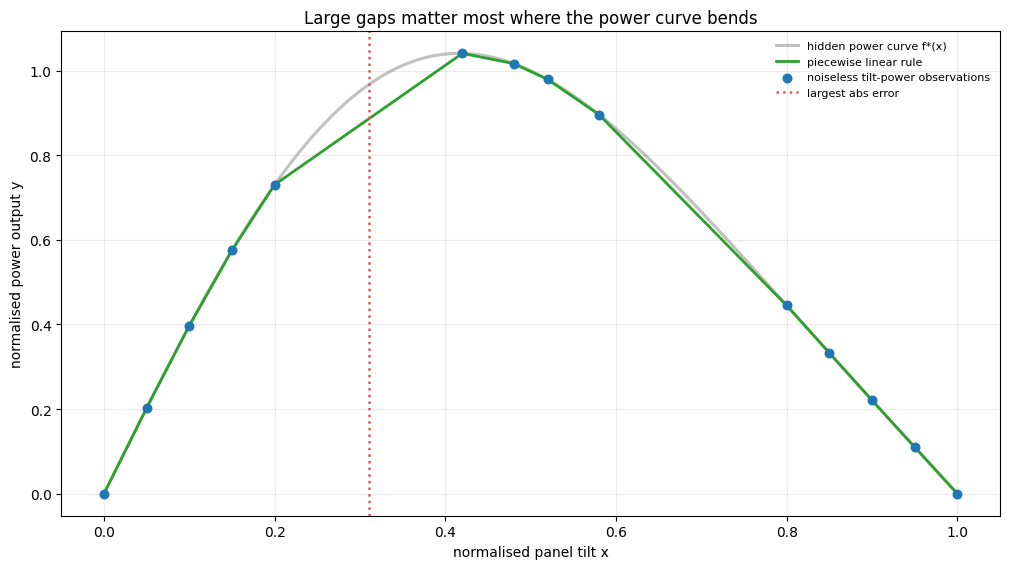

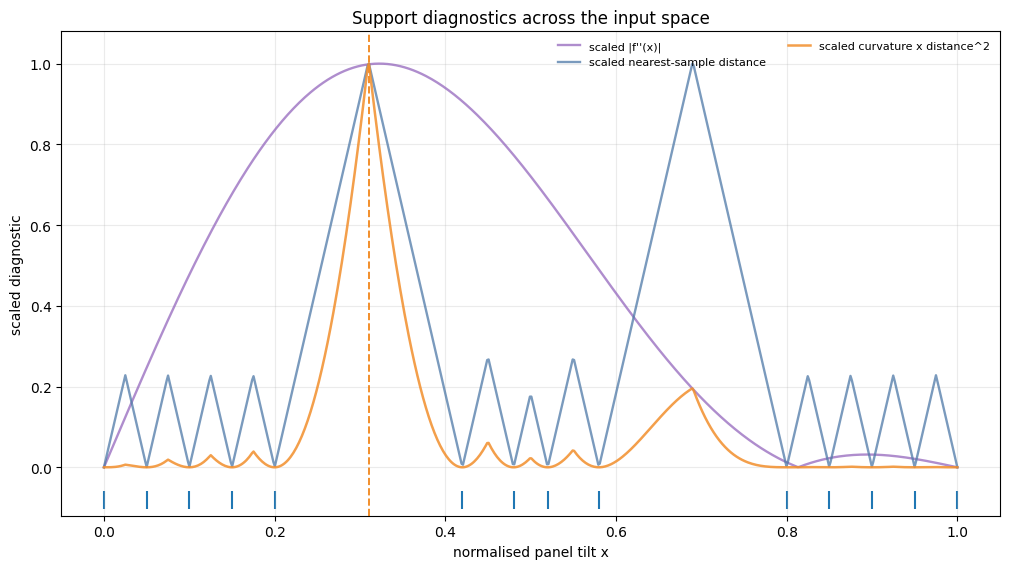

Curvature and spacing diagnostics for a simple interpolating rule
01. max_error_x=0.3105, abs_error=0.0809, nearest_sample_distance=0.1095, scaled_curvature_at_max_error=0.9984
02. max_risk_score_x=0.3105, risk_score=1.0000, abs_error_at_max_risk=0.0809, nearest_sample_distance=0.1095


In [8]:
# Relate interpolation error to curvature and local sample spacing in a controlled noiseless example.
x_support = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.42, 0.48, 0.52, 0.58, 0.80, 0.85, 0.90, 0.95, 1.00])
y_support = data.true_function(x_support)
y_true_grid = data.true_function(x_grid)
y_linear = np.interp(x_grid, x_support, y_support)
abs_error = np.abs(y_linear - y_true_grid)
nearest_support_distance = np.min(np.abs(x_grid[:, None] - x_support[None, :]), axis=1)

def scale01(values):
    max_value = float(np.max(values))
    if max_value == 0.0:
        return values
    return values / max_value

distance_scaled = scale01(nearest_support_distance)
risk_score = scale01(curvature * nearest_support_distance**2)
max_error_index = int(np.argmax(abs_error))
max_risk_index = int(np.argmax(risk_score))

fig_function, ax_function = plt.subplots(figsize=(10.2, 5.8))
ax_function.plot(x_grid, y_true_grid, color="#777777", alpha=0.45, linewidth=2.2, label="hidden power curve f*(x)")
ax_function.plot(x_grid, y_linear, color="#2ca02c", linewidth=2.0, label="piecewise linear rule")
ax_function.scatter(x_support, y_support, s=38, color="#1f77b4", zorder=3, label="noiseless tilt-power observations")
ax_function.axvline(x_grid[max_error_index], color="#e15759", linestyle=":", linewidth=1.8, label="largest abs error")
ax_function.set_title("Large gaps matter most where the power curve bends")
ax_function.set_xlabel("normalised panel tilt x")
ax_function.set_ylabel("normalised power output y")
ax_function.grid(alpha=0.25)
ax_function.legend(frameon=False, fontsize=8)
fig_function.tight_layout()
show_fig(fig_function)

fig_diag, ax_diag = plt.subplots(figsize=(10.2, 5.8))
ax_diag.plot(x_grid, curvature_scaled, color="#9467bd", linewidth=1.7, alpha=0.75, label="scaled |f''(x)|")
ax_diag.plot(x_grid, distance_scaled, color="#4e79a7", linewidth=1.7, alpha=0.75, label="scaled nearest-sample distance")
ax_diag.plot(x_grid, risk_score, color="#f28e2b", linewidth=1.8, alpha=0.85, label="scaled curvature x distance^2")
ax_diag.scatter(x_support, np.zeros_like(x_support) - 0.08, marker="|", s=150, color="#1f77b4")
ax_diag.axvline(x_grid[max_risk_index], color="#f28e2b", linestyle="--", linewidth=1.4)
ax_diag.set_title("Support diagnostics across the input space")
ax_diag.set_xlabel("normalised panel tilt x")
ax_diag.set_ylabel("scaled diagnostic")
ax_diag.set_ylim(-0.12, 1.08)
ax_diag.grid(alpha=0.25)
ax_diag.legend(frameon=False, fontsize=8, ncol=2)
fig_diag.tight_layout()
show_fig(fig_diag)

print_rows(
    [
        {
            "max_error_x": x_grid[max_error_index],
            "abs_error": abs_error[max_error_index],
            "nearest_sample_distance": nearest_support_distance[max_error_index],
            "scaled_curvature_at_max_error": curvature_scaled[max_error_index],
        },
        {
            "max_risk_score_x": x_grid[max_risk_index],
            "risk_score": risk_score[max_risk_index],
            "abs_error_at_max_risk": abs_error[max_risk_index],
            "nearest_sample_distance": nearest_support_distance[max_risk_index],
        },
    ],
    digits=4,
    title="Curvature and spacing diagnostics for a simple interpolating rule",
)


<br>

## 5. Distinguish Interpolation, Gaps, and Extrapolation

Naming the region clarifies what kind of trust is being requested.

Now define the regions in plain language.

- **Well-supported interpolation:** the prediction point is inside the observed range and has nearby training points.
- **Gap interpolation:** the prediction point is inside the observed range, but it lies far from nearby training points.
- **Extrapolation:** the prediction point is outside the smallest and largest observed training inputs.

The middle case is easy to miss. A point can be between the smallest and largest measured panel-tilt settings while still being weakly constrained by $\mathcal{D}$. A gap between clusters gives plausible fitted functions room to separate.

There is no universal guarantee that interpolation will be good or extrapolation will be bad. The safer claim is narrower: interpolation is easier to defend when the target is smooth, noise is controlled, the model class is appropriate, and the point has nearby evidence. Extrapolation needs extra assumptions, because there is no nearby data to correct the model if those assumptions are wrong.

This matters for the generalisation argument. If a model performs poorly in a specific region, that failure is information. It tells us where the dataset weakly constrained $\hat{\theta}$ and where new measurements may be most valuable.

> **Predict before running.** In the next cells, the data pattern and optimizer are fixed within each case, but the polynomial degree changes. Which region should be most sensitive to the hypothesis space: a well-supported part of the measured range, a gap inside the measured range, or a high-tilt extrapolation region? Write down your expectation before revealing the fitted curves.



### Implementation reveal: masks define evaluation regimes
The next code cell turns words like well-supported interpolation, gap interpolation, extrapolation, and deployment region into Boolean masks over the input grid. That small implementation detail matters: every reported error is attached to a region definition, not just to the model as a whole.



In [ ]:
# Evaluate the same fitted rule by evidence regime, then compare hypothesis-space choices.
coverage_degrees = [3, 9]
coverage_noise_std = 0.20
coverage_seed = 2026
probe_x = 0.78
deployment_tilt_region = (0.60, 0.90)
support_radius = 0.06

x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
region_min, region_max = deployment_tilt_region
deployment_mask = (x_grid >= region_min) & (x_grid <= region_max)

coverage_cases = [
    {
        "case": "clustered evidence: internal gap",
        "sampling": "clustered",
    },
    {
        "case": "partial-domain evidence: high-tilt extrapolation",
        "sampling": "partial_domain",
    },
]

coverage_results = []
support_rows = []
coverage_rows = []


def fmt_metric(value):
    if value is None or np.isnan(value):
        return "n/a"
    return f"{float(value):.3f}"


def summarise_region(mask, nearest_distance, prediction):
    if not np.any(mask):
        return {
            "n_grid_points": 0,
            "max_nearest_distance": np.nan,
            "oracle_mse": np.nan,
            "max_abs_error": np.nan,
        }
    abs_error = np.abs(prediction[mask] - y_grid_true[mask])
    return {
        "n_grid_points": int(np.sum(mask)),
        "max_nearest_distance": float(np.max(nearest_distance[mask])),
        "oracle_mse": metrics.mse(y_grid_true[mask], prediction[mask]),
        "max_abs_error": float(np.max(abs_error)),
    }


for settings in coverage_cases:
    x_cov, y_cov = data.make_regression_data(
        n=26,
        noise_std=coverage_noise_std,
        seed=coverage_seed,
        sampling=settings["sampling"],
    )

    nearest_distance = np.min(np.abs(x_grid[:, None] - x_cov[None, :]), axis=1)
    inside_observed_range = (x_grid >= np.min(x_cov)) & (x_grid <= np.max(x_cov))
    left_extrapolation = x_grid < np.min(x_cov)
    right_extrapolation = x_grid > np.max(x_cov)
    outside_range = left_extrapolation | right_extrapolation

    internal_gaps = np.diff(x_cov)
    gap_index = int(np.argmax(internal_gaps))
    gap_min = float(x_cov[gap_index])
    gap_max = float(x_cov[gap_index + 1])
    gap_bounds = (gap_min, gap_max)
    gap_mask = inside_observed_range & (x_grid >= gap_min) & (x_grid <= gap_max)
    well_supported_mask = inside_observed_range & (nearest_distance <= support_radius) & ~gap_mask

    probe_distance = float(np.min(np.abs(x_cov - probe_x)))
    if probe_x < np.min(x_cov) or probe_x > np.max(x_cov):
        probe_status = "extrapolation"
    elif gap_min <= probe_x <= gap_max:
        probe_status = "inside largest gap"
    elif probe_distance <= support_radius:
        probe_status = "well-supported interpolation"
    else:
        probe_status = "sparse interpolation"

    deployment_nearest_distance = nearest_distance[deployment_mask]
    deployment_extrapolation_fraction = float(np.mean(outside_range[deployment_mask]))
    support_rows.append(
        {
            "case": settings["case"],
            "x_min": np.min(x_cov),
            "x_max": np.max(x_cov),
            "largest_internal_gap": np.max(internal_gaps),
            "deployment_fill_distance": np.max(deployment_nearest_distance),
            "deployment_extrapolation_fraction": deployment_extrapolation_fraction,
            "probe_x": probe_x,
            "probe_nearest_distance": probe_distance,
            "probe_status": probe_status,
        }
    )

    regime_masks = {
        "well_supported_interpolation": {
            "kind": "interpolation",
            "mask": well_supported_mask,
        },
        "largest_internal_gap": {
            "kind": "gap interpolation",
            "mask": gap_mask,
        },
        "outside_observed_range": {
            "kind": "extrapolation",
            "mask": outside_range,
        },
        "deployment_region": {
            "kind": "deployment target",
            "mask": deployment_mask,
        },
    }

    for degree in coverage_degrees:
        coeffs = models.fit_polynomial_mle(x_cov, y_cov, degree=degree)
        train_pred = models.predict_polynomial(x_cov, coeffs)
        grid_pred = models.predict_polynomial(x_grid, coeffs)
        train_mse = metrics.mse(y_cov, train_pred)
        theta_norm = metrics.coefficient_norm(coeffs)
        metrics_by_region = {}

        for region_name, region_spec in regime_masks.items():
            region_summary = summarise_region(
                region_spec["mask"],
                nearest_distance=nearest_distance,
                prediction=grid_pred,
            )
            metrics_by_region[region_name] = region_summary
            coverage_rows.append(
                {
                    "case": settings["case"],
                    "degree": degree,
                    "region": region_name,
                    "region_kind": region_spec["kind"],
                    "max_nearest_distance": region_summary["max_nearest_distance"],
                    "oracle_mse": region_summary["oracle_mse"],
                    "max_abs_error": region_summary["max_abs_error"],
                    "train_mse": train_mse,
                    "theta_norm_warning": theta_norm,
                }
            )

        coverage_results.append(
            {
                "case": settings["case"],
                "degree": degree,
                "x": x_cov,
                "y": y_cov,
                "grid_pred": grid_pred,
                "gap_mask": gap_mask,
                "gap_bounds": gap_bounds,
                "left_extrapolation": left_extrapolation,
                "right_extrapolation": right_extrapolation,
                "train_mse": train_mse,
                "metrics_by_region": metrics_by_region,
            }
        )

print_rows(support_rows, digits=4, title="Support regions defined from the training inputs")
print()
print_rows(coverage_rows, digits=4, title="Region-specific evaluation of the fitted rule")



In [ ]:
# Visualise where each fitted function is supported and where it is weakly constrained.
for settings in coverage_cases:
    case_results = [result for result in coverage_results if result["case"] == settings["case"]]
    fig, axes = plt.subplots(1, len(case_results), figsize=(13.2, 5.4), sharex=True, sharey=True)
    if len(case_results) == 1:
        axes = [axes]

    for ax, result in zip(axes, case_results):
        ax.axvspan(region_min, region_max, color="#4e79a7", alpha=0.10, label="deployment tilt region")
        ax.axvline(probe_x, color="#4e79a7", linestyle=":", linewidth=1.8, label="probe tilt")
        if np.any(result["gap_mask"]):
            gap_x = x_grid[result["gap_mask"]]
            ax.axvspan(gap_x.min(), gap_x.max(), color="#f2c94c", alpha=0.24, label="largest internal gap")
        if np.any(result["left_extrapolation"]):
            left_x = x_grid[result["left_extrapolation"]]
            ax.axvspan(left_x.min(), left_x.max(), color="#e76f51", alpha=0.12, label="outside observed tilt range")
        if np.any(result["right_extrapolation"]):
            right_x = x_grid[result["right_extrapolation"]]
            ax.axvspan(right_x.min(), right_x.max(), color="#e76f51", alpha=0.12, label="outside observed tilt range")

        ax.scatter(result["x"], result["y"], s=34, color="#1f77b4", label="training evidence")
        ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
        ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0, label="fitted rule")

        region_metrics = result["metrics_by_region"]
        metric_text = "\n".join(
            [
                f"train MSE: {fmt_metric(result['train_mse'])}",
                f"supported MSE: {fmt_metric(region_metrics['well_supported_interpolation']['oracle_mse'])}",
                f"gap MSE: {fmt_metric(region_metrics['largest_internal_gap']['oracle_mse'])}",
                f"outside MSE: {fmt_metric(region_metrics['outside_observed_range']['oracle_mse'])}",
                f"deploy MSE: {fmt_metric(region_metrics['deployment_region']['oracle_mse'])}",
            ]
        )
        ax.text(
            0.03,
            0.04,
            metric_text,
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
            ha="left",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.82, "edgecolor": "#dddddd"},
        )
        ax.set_title(f"degree {result['degree']}")
        ax.set_xlabel("normalised panel tilt x")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-2.0, 2.0)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("normalised power output y")
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=4, frameon=False, fontsize=8)
    fig.suptitle(settings["case"], y=0.99)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))
    show_fig(fig)



**Diagnose Support by Regime**

The shaded regions mark different ways evidence can be weak. Yellow marks the largest internal gap found from the sampled data itself. Red marks predictions outside the measured panel-tilt range. Blue marks a chosen deployment tilt region $\Omega$, and the dotted line is a probe point you can change and rerun.

Read the summary by region, not just by average. The same fitted rule can have a small training error, a tolerable error where evidence is nearby, and a much larger error in a gap or outside the observed range.

Compare the two degrees within each data pattern. Where the data are dense, the two hypothesis spaces may behave similarly because the evidence constrains both. Where the data are sparse, gapped, or absent, the form of the hypothesis space matters more: a low-degree polynomial and a high-degree polynomial can make very different claims while both remaining compatible with the training observations.

Before collecting more solar-panel power readings, discuss which evidence would change your mind most: panel-tilt settings in the largest internal gap, settings outside the current range, repeated power readings at existing settings to estimate noise, or measurements targeted to the deployment tilt region.

The oracle MSE columns compare predictions with the hidden function because this is a simulation. In real work, analogous diagnostics would come from targeted solar-panel check measurements, held-out power readings from the relevant panel-tilt region, or domain-specific validation.



<br>

## 6. Change the Data Space, Not the Model Class

Changing evidence can change trust while model class and fitting rule stay fixed.


Now keep the hypothesis space and fitting rule fixed, but change $\mathcal{D}$.

This mirrors the earlier notebooks: change one part of the learning frame while holding the others still. Here $\mathcal{H}$ and $\mathcal{O}$ stay fixed, while the data space changes through sample count, clustering, noise, and missing support.

If the selected function changes dramatically under a new data distribution, the diagnosis points toward evidence support. The sample may be thin, noisy, clustered, or missing in the region where predictions matter.

More evidence helps most when it improves coverage of $\Omega$. More observations in an already-supported region may leave the generalisation argument almost unchanged.

Before running the intervention cells, predict which case will have the worst deployment or grid error and why. Change one data-space feature at a time: sample count, clustering, noise, or support.


### 6.1 Before running: predict data-space interventions

The next cells hold degree and fitting rule fixed while changing the data. Fill this table before running.

| Data intervention | Expected effect on support | Expected effect on error | Why? |
|---|---|---|---|
| More uniform data | | | |
| Clustered data | | | |
| Higher noise | | | |
| Partial domain | | | |


### Group experiment: change evidence, not the model
Assign each group one data intervention from the next cell. Keep the model class and fitting rule fixed. Before running, each group should predict how its evidence design changes:

- support near the deployment region;
- average error;
- the parts of the curve that become least defensible.

This keeps the lesson focused: sometimes the right fix is better evidence, not a more flexible model.


In [11]:
# Same fitting rule, different data spaces.
intervention_degree = 9
intervention_seed = 2026
interventions = [
    {"label": "uniform", "n": 20, "noise": 0.20, "sampling": "uniform"},
    {"label": "more data", "n": 80, "noise": 0.20, "sampling": "uniform"},
    {"label": "clustered", "n": 20, "noise": 0.20, "sampling": "clustered"},
    {"label": "higher noise", "n": 20, "noise": 0.45, "sampling": "uniform"},
    {"label": "partial domain", "n": 20, "noise": 0.20, "sampling": "partial_domain"},
]

x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
intervention_results = []
intervention_rows = []

for settings in interventions:
    x_int, y_int = data.make_regression_data(
        n=settings["n"],
        noise_std=settings["noise"],
        seed=intervention_seed,
        sampling=settings["sampling"],
    )
    coeffs = models.fit_polynomial_mle(x_int, y_int, degree=intervention_degree)
    train_pred = models.predict_polynomial(x_int, coeffs)
    grid_pred = models.predict_polynomial(x_grid, coeffs)

    intervention_results.append(
        {
            "settings": settings,
            "x": x_int,
            "y": y_int,
            "grid_pred": grid_pred,
        }
    )
    intervention_rows.append(
        {
            "case": settings["label"],
            "n": settings["n"],
            "x_min": np.min(x_int),
            "x_max": np.max(x_int),
            "train_mse": metrics.mse(y_int, train_pred),
            "oracle_grid_mse": metrics.mse(y_grid_true, grid_pred),
            "coef_norm": metrics.coefficient_norm(coeffs),
        }
    )

print_rows(intervention_rows, digits=4, title="Predict which cases will be fragile before looking at the plots")


Predict which cases will be fragile before looking at the plots
01. case=uniform, n=20, x_min=0.1774, x_max=0.9670, train_mse=0.0171, oracle_grid_mse=181.4153, coef_norm=1.68e+06
02. case=more data, n=80, x_min=0.0018, x_max=0.9897, train_mse=0.0429, oracle_grid_mse=0.0030, coef_norm=2.21e+04
03. case=clustered, n=20, x_min=0.1073, x_max=0.7904, train_mse=0.0182, oracle_grid_mse=389.2473, coef_norm=6.18e+06
04. case=higher noise, n=20, x_min=0.1774, x_max=0.9670, train_mse=0.0867, oracle_grid_mse=918.4114, coef_norm=3.78e+06
05. case=partial domain, n=20, x_min=0.1241, x_max=0.6769, train_mse=0.0171, oracle_grid_mse=3.84e+06, coef_norm=1.63e+07


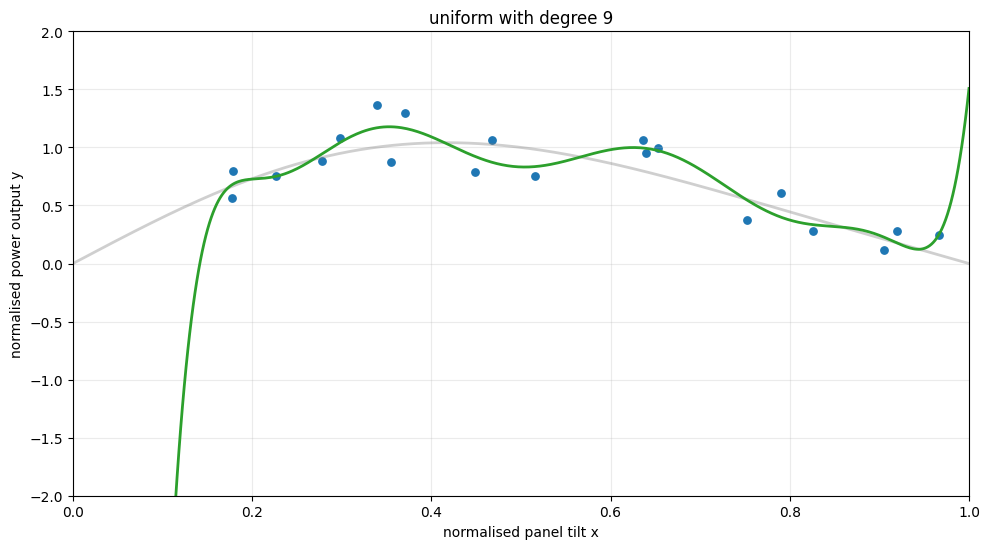

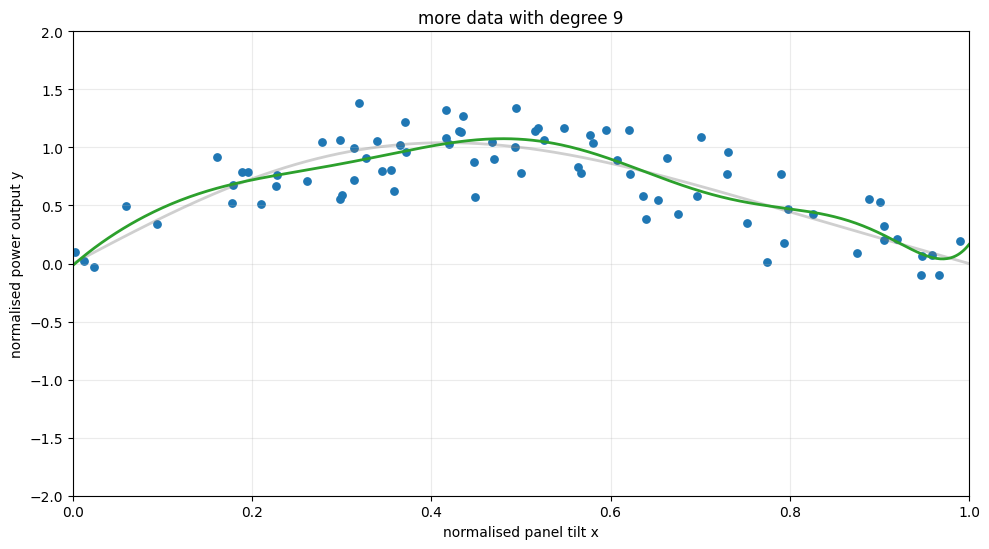

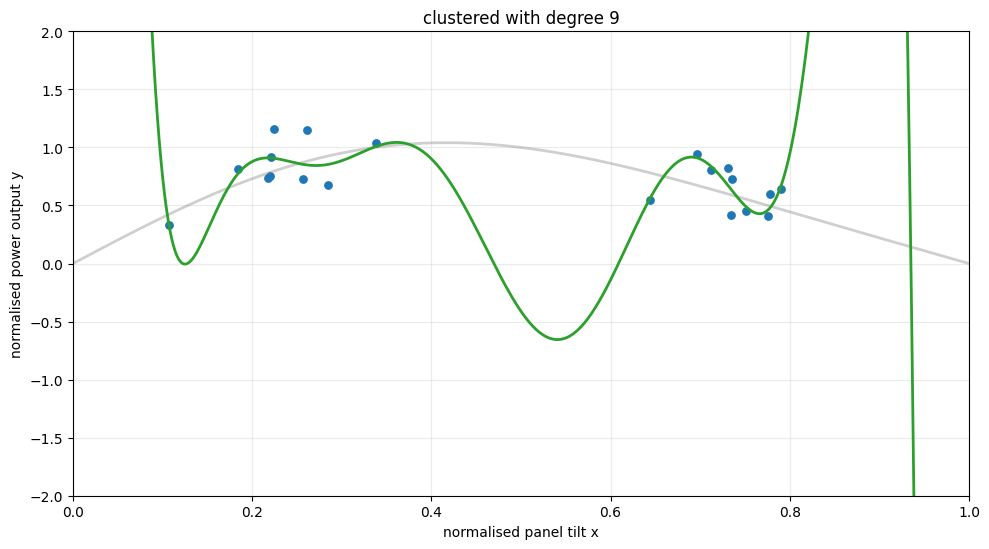

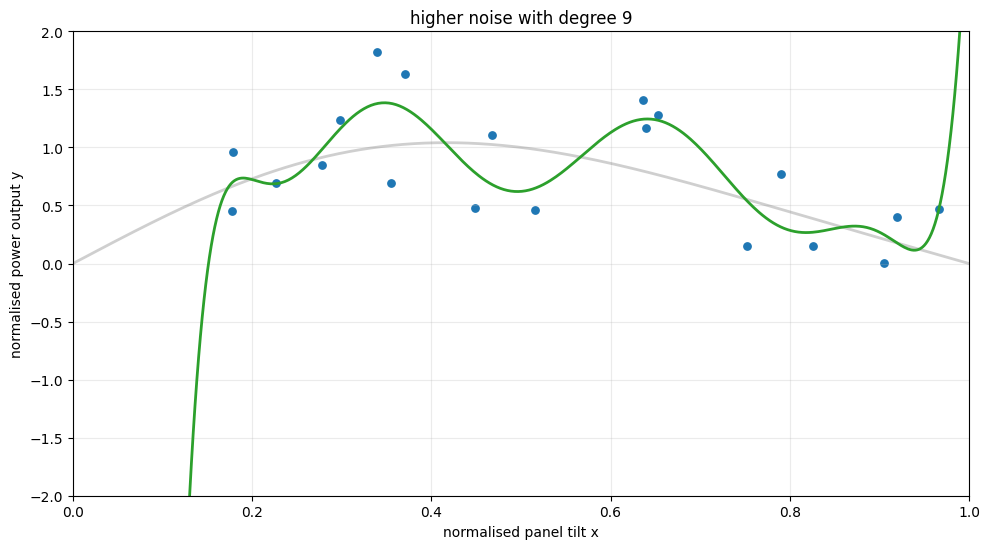

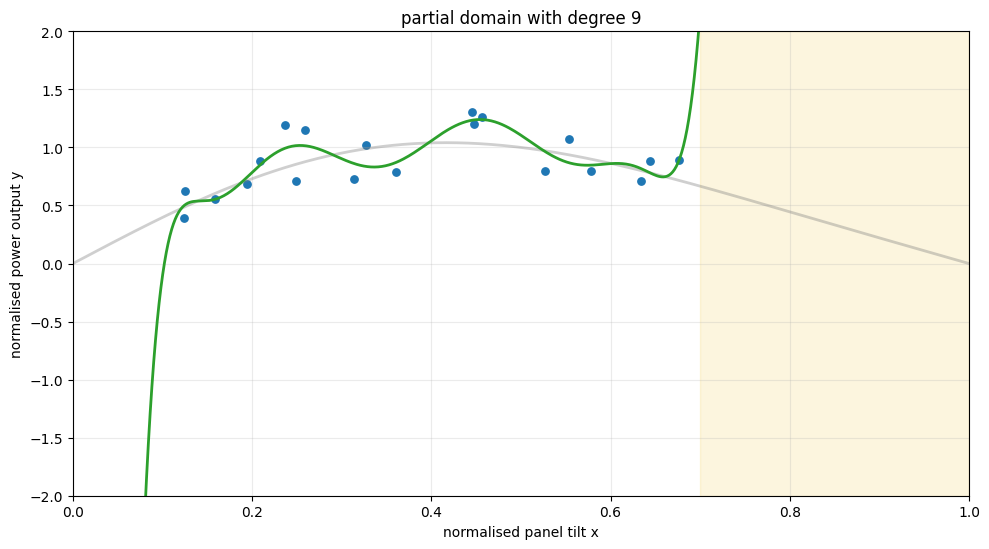

In [12]:
# Plot the same fitting rule under different data-space choices.
for result in intervention_results:
    settings = result["settings"]
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.scatter(result["x"], result["y"], s=28, color="#1f77b4")
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0)
    ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0)
    if settings["sampling"] == "partial_domain":
        ax.axvspan(0.70, 1.00, color="#f2c94c", alpha=0.18)
    ax.set_title(f"{settings['label']} with degree {intervention_degree}")
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("normalised power output y")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    show_fig(fig)


**Diagnose the Data-Space Intervention**

More data helps most when it improves coverage where predictions are needed. Clustered data can look large while leaving blind spots. Partial-domain data can look good where evidence exists and unstable where it is absent.

`oracle_grid_mse` is available only because this is a simulation. The coefficient norm is a warning sign, not a universal rule; in a monomial basis, large coefficients often travel with oscillation and poor conditioning.

### Optional extension: larger AI systems

The same support question applies to larger systems:

> What evidence supports this behaviour, and where is the system travelling on assumptions?

A weak region might be a task type, context pattern, document source, tool state, action sequence, subgroup, or deployment scenario.

For scientists and engineers, failure is information. It can point to the next measurement, denser sampling, cleaner power readings, targeted evaluation, or a different hypothesis space.

In $\mathcal{H}+\mathcal{D}+\mathcal{O}$ terms, this section kept degree and least squares fixed while changing the evidence. When the curve moved, the diagnosis was data support.

> **Discuss.** If you had budget for ten new observations, where would you place them? Say whether each one reduces a gap, checks extrapolation, estimates noise, or challenges $\mathcal{H}$.


<br>

## 7. Checkpoint: Make a Generalisation Argument

A defensible model choice is an argument, not just a score.


Fit several polynomial degrees, compare training and validation MSE, inspect the validation-only plot, and choose a degree you would defend as a scientific explanation.

Build the argument explicitly:

- What hypothesis space $\mathcal{H}$ did the chosen degree allow?
- What evidence did $\mathcal{D}_{train}$ use to select $\hat{\theta}$?
- What role did validation evidence play in selecting the modelling choice?
- Where is the selected rule supported or weakly supported in $\Omega$?
- Which result would change your mind?

Commit to a degree before running the final test cell. Write it down, then reveal the test MSE once as a final check. Did your validation-based choice transfer to the held-out test set?

After that, change `checkpoint_noise_std`, `checkpoint_n_samples`, or `checkpoint_sampling`. Does your argument still hold?

The aim is not to find a magic degree. The aim is to defend why a selected $s$ should, or should not, be treated as belonging to the acceptable solution space $\mathcal{S}$ for the intended use.


### 7.1 Generalisation argument template

Before revealing the final test result, write your claim in this form:

> We selected [model/workflow] from [hypothesis space] using [training evidence] and [optimization rule]. We chose modelling settings using [validation evidence]. We will check the settled workflow on [test evidence]. We trust the selected rule in [deployment region] because [support/evaluation argument]. We would not trust it in [unsupported region] without [additional evidence].

This template is deliberately demanding. It forces the claim to name the model, data, optimization, evidence roles, and deployment region.


Checkpoint model choices using train and validation only
01. degree=0, train_mse=0.2008, validation_mse=0.1213, coef_norm_warning=0.8688
02. degree=1, train_mse=0.1365, validation_mse=0.1057, coef_norm_warning=1.8946
03. degree=3, train_mse=0.0243, validation_mse=0.0491, coef_norm_warning=45.6689
04. degree=5, train_mse=0.0238, validation_mse=0.0503, coef_norm_warning=425.9456
05. degree=9, train_mse=0.0163, validation_mse=41.4206, coef_norm_warning=7.12e+06
06. degree=15, train_mse=0.0036, validation_mse=2.49e+04, coef_norm_warning=1.51e+11
Validation minimum
01. criterion=lowest_validation_mse, degree=3, train_mse=0.0243, validation_mse=0.0491, coef_norm_warning=45.6689
Default selected_degree is 3. Edit selected_degree before the final test if your argument chooses another degree.
Commit to a degree now. Run the next cell only after the choice is written down.


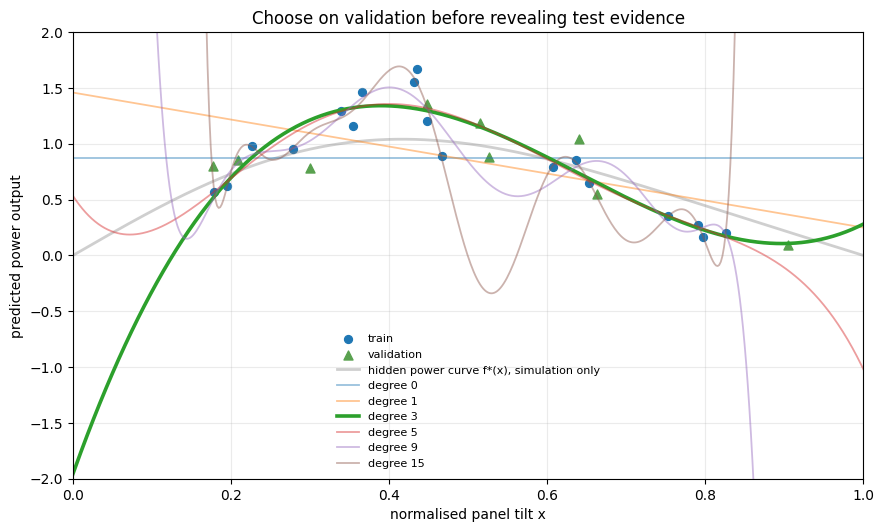

In [13]:
# Checkpoint working cell. Edit, rerun, and defend a model choice using train and validation only.
checkpoint_n_samples = 36
checkpoint_noise_std = 0.20
checkpoint_seed = 2026
checkpoint_sampling = "uniform"
checkpoint_degrees = (0, 1, 3, 5, 9, 15)

x_ckpt, y_ckpt = data.make_regression_data(
    n=checkpoint_n_samples,
    noise_std=checkpoint_noise_std,
    seed=checkpoint_seed,
    sampling=checkpoint_sampling,
)
x_build_ckpt, y_build_ckpt, x_test_ckpt, y_test_ckpt = data.train_test_split_for_workshop(
    x_ckpt,
    y_ckpt,
    test_size=0.25,
    seed=checkpoint_seed + 1,
)
x_train_ckpt, y_train_ckpt, x_val_ckpt, y_val_ckpt = data.train_test_split_for_workshop(
    x_build_ckpt,
    y_build_ckpt,
    test_size=0.33,
    seed=checkpoint_seed + 2,
)

checkpoint_rows = []
checkpoint_fits = {}
checkpoint_coeffs = {}
x_grid = data.make_test_grid(n_points=500)
for degree in checkpoint_degrees:
    coeffs = models.fit_polynomial_mle(x_train_ckpt, y_train_ckpt, degree=degree)
    train_pred = models.predict_polynomial(x_train_ckpt, coeffs)
    val_pred = models.predict_polynomial(x_val_ckpt, coeffs)
    checkpoint_coeffs[degree] = coeffs
    checkpoint_fits[degree] = models.predict_polynomial(x_grid, coeffs)
    checkpoint_rows.append(
        {
            "degree": degree,
            "train_mse": metrics.mse(y_train_ckpt, train_pred),
            "validation_mse": metrics.mse(y_val_ckpt, val_pred),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
        }
    )

best_validation = min(checkpoint_rows, key=lambda row: row["validation_mse"])
validation_suggested_degree = int(best_validation["degree"])
selected_degree = validation_suggested_degree  # Edit this before the final test if your written argument chooses another degree.

print_rows(checkpoint_rows, digits=4, title="Checkpoint model choices using train and validation only")
print_rows([{"criterion": "lowest_validation_mse", **best_validation}], digits=4, title="Validation minimum")
print(f"Default selected_degree is {selected_degree}. Edit selected_degree before the final test if your argument chooses another degree.")
print("Commit to a degree now. Run the next cell only after the choice is written down.")

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_ckpt, y_train_ckpt, s=32, color="#1f77b4", label="train")
ax.scatter(x_val_ckpt, y_val_ckpt, s=42, marker="^", color="#59a14f", label="validation")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x), simulation only")
for degree in checkpoint_degrees:
    linewidth = 2.6 if degree == selected_degree else 1.3
    alpha = 1.0 if degree == selected_degree else 0.45
    ax.plot(x_grid, checkpoint_fits[degree], linewidth=linewidth, alpha=alpha, label=f"degree {degree}")
ax.set_title("Choose on validation before revealing test evidence")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("predicted power output")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
show_fig(fig)


**Final Test Reveal**

Run the next cell only after the model choice has been written down. This cell uses the untouched test split for the validation-selected degree and should not be used to keep tuning the workflow.


Final test check for the validation-selected model only
01. selected_degree=3, validation_mse=0.0491, test_mse_final_check=0.3541


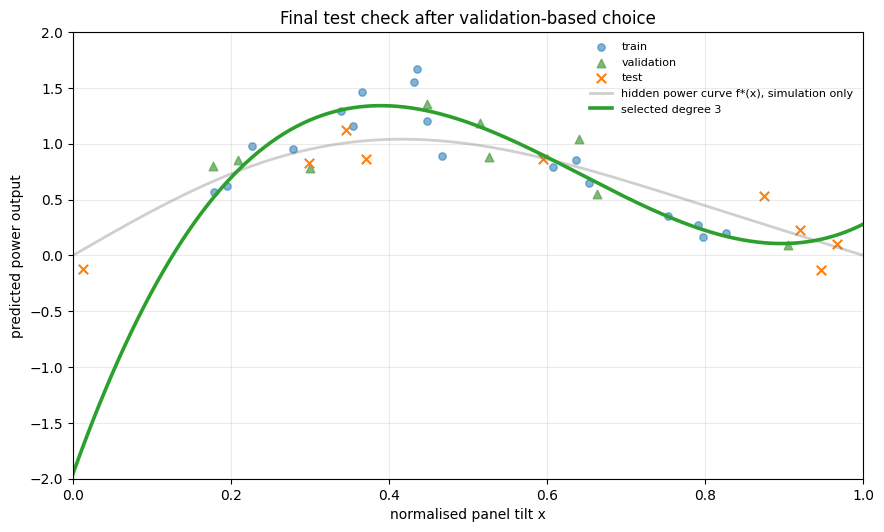

In [14]:
# Final test check. Run once after committing to a degree.
selected_test_pred = models.predict_polynomial(x_test_ckpt, checkpoint_coeffs[selected_degree])
selected_test_mse = metrics.mse(y_test_ckpt, selected_test_pred)

print_rows(
    [
        {
            "selected_degree": selected_degree,
            "validation_mse": best_validation["validation_mse"],
            "test_mse_final_check": selected_test_mse,
        }
    ],
    digits=4,
    title="Final test check for the validation-selected model only",
)

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_ckpt, y_train_ckpt, s=28, color="#1f77b4", alpha=0.55, label="train")
ax.scatter(x_val_ckpt, y_val_ckpt, s=38, marker="^", color="#59a14f", alpha=0.75, label="validation")
ax.scatter(x_test_ckpt, y_test_ckpt, s=46, marker="x", color="#ff7f0e", label="test")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x), simulation only")
ax.plot(x_grid, checkpoint_fits[selected_degree], color="#2ca02c", linewidth=2.6, label=f"selected degree {selected_degree}")
ax.set_title("Final test check after validation-based choice")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("predicted power output")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
show_fig(fig)


<br>

## 8. Summary: Generalisation as a Defensibility Argument

Generalisation is the evidence-based case that a selected rule is acceptable for use.


Notebook 03 asked which solution the machinery selected. Notebook 04 asks where that solution is defensible.

1. **Training evidence is not checking evidence.** Once held-out data steer choices, they become validation evidence.
2. **Split policy controls the claim.** Random splits check same-source performance. Structured splits check transfer across time, groups, sites, or regions.
3. **Support is local.** A global score can hide weak gaps, edges, noisy regions, or extrapolation.
4. **Overfitting is a travel problem.** A rule can fit selection data and fail on fresh cases.
5. **Interpolation needs assumptions.** Nearby evidence helps, but smoothness, noise, sampling, and model class still matter.
6. **Model choice is an argument.** Name $\mathcal{H}$, $\mathcal{D}$, $\mathcal{O}$, $\Omega$, and the diagnostics that would change the decision.

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s \quad \text{does not by itself prove} \quad s\in\mathcal{S}.
$$

Generalisation is the extra evidence-based argument that $s$ is acceptable for the intended region and use.


<br>

## 9. Evaluation Discipline Beyond This Notebook

Evaluation evidence must be separated according to the claim it supports.


Train, validation, and test splits protect different claims.

The training set selects parameters. It directly shapes coefficients, weights, prompts, thresholds, retrieval settings, or other configurable parts of the system.

The validation set selects choices around the model: degree, regularisation, features, early stopping, prompt wording, retrieval setup, tool policy, or cleaning decisions. Once it guides those choices, it is no longer an untouched final check.

The test set checks the settled workflow. If the test result triggers more tuning, it has become validation evidence and a new final check is needed.

Choose the split to match the claim. Random splits fit same-source future cases. Structured splits are better for transfer to a future time, new user group, new site, new document source, or new input region.

Watch for leakage. It can be obvious, such as training on test labels, or subtle, such as normalising before the split, deduplicating after the split, repeatedly inspecting test failures, or allowing near-duplicates across splits.

For larger ML and LLM systems, evaluate the whole workflow: retrieval, prompts, tools, post-processing, human review, safety filters, caching, and fallback policies. A benchmark becomes validation evidence once it steers these choices.

A defensible claim is not just "the score was good." It is: this settled workflow was checked on this untouched evidence for this intended region of use.

> **Discuss.** For a model, LLM workflow, or scientific analysis you know, what counts as training evidence, validation evidence, and final test evidence? Where could leakage enter?


<br>

## 10. Final reusable diagnostic

Use the final checklist to connect model behaviour back to the learning frame.


For any fitted model, ask:

| Question | Diagnostic role |
|---|---|
| What was the hypothesis space? | Names what could be represented. |
| What data selected the parameters? | Names the evidence that shaped the solution. |
| What optimization rule selected the solution? | Names the loss, penalty, and solver. |
| What validation evidence shaped modelling choices? | Names what guided tuning. |
| What test evidence remained untouched? | Names the final check. |
| Why was this split policy chosen? | Connects random or structured evaluation to the deployment claim. |
| Where is the deployment region $\Omega$? | Names where the solar-panel power model must work. |
| Which regions are interpolation, gaps, or extrapolation? | Names where nearby evidence supports the prediction and where it does not. |
| Where is the model weakly supported? | Names where not to trust the result without more evidence. |

**Final takeaway.** A model is not defensible because it has one good score. It is defensible when the hypothesis space, data evidence, optimization rule, and deployment region support the claim being made.


<br>

## 11. Optional Extension: Bridge to Notebook 05

The probabilistic extension gives losses, penalties, and uncertainty an assumptions-based reading.


The core Workshop 1 arc is now complete. We have inspected the evidence $\mathcal{D}$, the hypothesis space $\mathcal{H}$, the selection machinery $\mathcal{O}$, and the question of whether the selected solution belongs in the acceptable solution space $\mathcal{S}$ for future use.

Notebook 05 is optional. It does not replace the earlier diagnosis; it gives parts of it a probabilistic interpretation. A likelihood says what measurement story would make the observed residuals plausible. A prior says which hypotheses or parameters were plausible before this dataset arrived. Evidence and posterior uncertainty then become additional ways to ask whether the selected or summarised solution is defensible.


<br>

## 12. References

These references support the generalisation and evaluation ideas used here.


References for validation, generalisation diagnostics, interpolation error, data coverage, and active data collection.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). [*The Elements of Statistical Learning: Data Mining, Inference, and Prediction*](https://link.springer.com/book/10.1007/978-0-387-84858-7), 2nd ed. Model assessment, validation, test error, and model-complexity trade-offs.
- Stone, M. (1974). [*Cross-Validatory Choice and Assessment of Statistical Predictions*](https://academic.oup.com/jrsssb/article/36/2/111/7027414), *Journal of the Royal Statistical Society: Series B*, 36(2), 111-133. Classical support for using held-out evidence in model choice and assessment.
- Süli, E., & Mayers, D. F. (2003). [*An Introduction to Numerical Analysis*](https://www.cambridge.org/core/books/an-introduction-to-numerical-analysis/FD8BCAD7FE68002E2179DFF68B8B7237/listing). Interpolation error and the role of sample spacing and curvature in simple approximation settings.
- Wendland, H. (2004). [*Scattered Data Approximation*](https://www.cambridge.org/core/product/identifier/9780511617539/type/book). Fill distance, scattered-data geometry, and approximation error controlled by data coverage.
- Settles, B. (2009). [*Active Learning Literature Survey*](https://minds.wisconsin.edu/handle/1793/60660), Computer Sciences Technical Report 1648, University of Wisconsin-Madison. Turning model diagnostics into targeted data-collection questions.
